# AAA_t_test4: complex-grid filtered data with AAA_tube

This notebook follows the complex-grid workflow: compute exact data on a source complex tube, keep points where SCE or WCE is accurate, fit `AAA_tube` to the filtered data for one Matsubara frequency, then compare the AAA interpolation against the exact result on a full evaluation tube.

The source tube used to evaluate/filter SCE and WCE is intentionally separate from the tube settings passed into `AAA_tube`.


In [ ]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt

from t_complex_interpolation_workflow import (
    compute_exact_t,
    build_t_app_G_app,
)
from _bary_rational import AAA_tube, AAA_tube_v2


In [ ]:
# Hubbard dimer and Matsubara setup.
beta = 5.0
Ns = 2
Nw = 4 * int(beta)
Mat_fre = (2 * np.linspace(0, Nw - 1, Nw) + 1) * np.pi / beta
wn = np.append(-np.flip(Mat_fre), Mat_fre)

U = 8.0
T = 20.0
sce_order = 4
wce_order = 8
epsilon = 1e-4

# Select one Matsubara frequency.
n_fit = Nw - 1
print("selected Matsubara index:", n_fit)
print("selected omega:", wn[n_fit])


selected Matsubara index: 79
selected omega: -0.15707963267948966


In [ ]:
# Source tube for evaluating exact/SCE/WCE and filtering t_app, G_app.
source_tube_real_window = (-T, T)
source_tube_delta = 1
source_N_real = 501
source_N_imag = 201

# Separate AAA_tube pole/boundary constraint settings.
aaa_tube_real_window = (-T, T)
aaa_tube_delta = 0.15
aaa_tube_Ns = 100000
max_terms = 10
max_error = epsilon

# Full tube where the final AAA interpolant is evaluated and compared to exact.
eval_tube_real_window = (-T, T)
eval_tube_delta = 1
eval_N_real = 501
eval_N_imag = 201


In [ ]:
def make_tube_lattice(real_window, delta, n_real, n_imag):
    lo, hi = real_window
    real_axis = np.linspace(lo, hi, n_real)
    imag_axis = np.linspace(-delta, delta, n_imag)
    real_grid, imag_grid = np.meshgrid(real_axis, imag_axis)
    t_grid = real_grid + 1j * imag_grid
    return real_grid, imag_grid, t_grid


def tube_boundary(real_window, delta):
    lo, hi = real_window
    return np.array([
        lo - 1j * delta,
        hi - 1j * delta,
        hi + 1j * delta,
        lo + 1j * delta,
        lo - 1j * delta,
    ])


def lattice_field_from_points(t_points, values, real_grid, imag_grid):
    field = np.full(real_grid.shape, np.nan, dtype=float)
    real_axis = real_grid[0]
    imag_axis = imag_grid[:, 0]
    real_step = real_axis[1] - real_axis[0]
    imag_step = imag_axis[1] - imag_axis[0]

    real_idx = np.rint((t_points.real - real_axis[0]) / real_step).astype(int)
    imag_idx = np.rint((t_points.imag - imag_axis[0]) / imag_step).astype(int)
    in_bounds = (
        (real_idx >= 0) & (real_idx < real_axis.size)
        & (imag_idx >= 0) & (imag_idx < imag_axis.size)
    )
    field[imag_idx[in_bounds], real_idx[in_bounds]] = values[in_bounds]
    return field


In [ ]:
# Build the source tube grid and exact baseline on that grid.
source_real_grid, source_imag_grid, source_t_grid = make_tube_lattice(
    source_tube_real_window,
    source_tube_delta,
    source_N_real,
    source_N_imag,
)
source_t_values = source_t_grid.ravel()
source_boundary = tube_boundary(source_tube_real_window, source_tube_delta)

G_exact_source = compute_exact_t(source_t_values, np.array([wn[n_fit]]), U, beta)[:, 0]

print("source tube grid shape:", source_t_grid.shape)
print("source tube point count:", source_t_values.size)
print("G_exact_source shape:", G_exact_source.shape)


source tube grid shape: (201, 501)
source tube point count: 100701
G_exact_source shape: (100701, 2, 2)


In [ ]:
# Filter the source tube to points where SCE or WCE is within epsilon.
t_app, G_app = build_t_app_G_app(
    sce_order=sce_order,
    wce_order=wce_order,
    baseline_G=G_exact_source,
    t_values=source_t_values,
    epsilon=epsilon,
    wn=wn[n_fit],
    U=U,
    beta=beta,
)

G_exact_app = compute_exact_t(t_app, np.array([wn[n_fit]]), U, beta)[:, 0]
app_error = np.max(np.abs(G_app - G_exact_app), axis=(1, 2))

print("t_app shape:", t_app.shape)
print("G_app shape:", G_app.shape)
print("max filtered data error:", np.max(app_error) if app_error.size else np.nan)
print("epsilon:", epsilon)


Selected matrix complex t points: 81579 of 100701 | SCE valid: 247 | WCE valid: 81332
t_app shape: (81579,)
G_app shape: (81579, 2, 2)
max filtered data error: 0.0009963821666415065
epsilon: 0.001


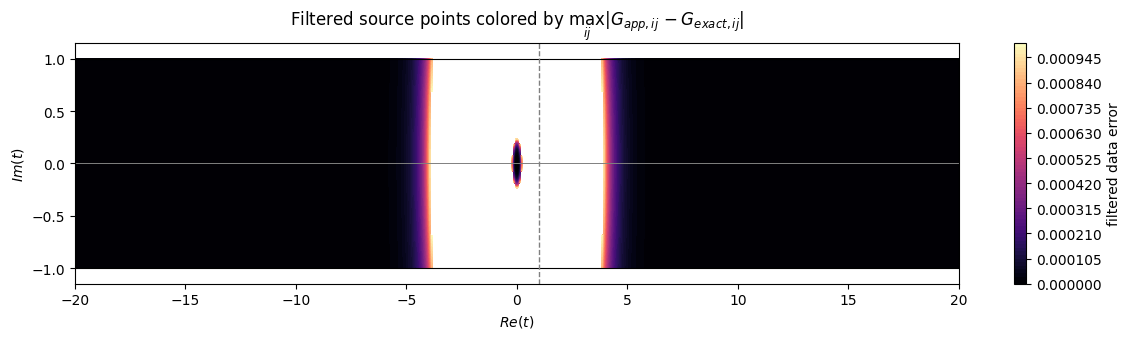

In [ ]:
# Visualize the filtered source points used for AAA fitting.
fig, ax = plt.subplots(figsize=(12, 3.5))
field = lattice_field_from_points(t_app, app_error, source_real_grid, source_imag_grid)
cf = ax.contourf(source_real_grid, source_imag_grid, field, levels=80, cmap="magma")
ax.plot(source_boundary.real, source_boundary.imag, color="k", linewidth=0.8)
ax.axhline(0, color="0.5", linewidth=0.7)
ax.axvline(1, color="gray", linestyle="--", linewidth=1)
ax.set_title(r"Filtered source points colored by $\max_{ij}|G_{app,ij} - G_{exact,ij}|$")
ax.set_xlabel(r"$Re(t)$")
ax.set_ylabel(r"$Im(t)$")
ax.set_ylim(-1.15 * source_tube_delta, 1.15 * source_tube_delta)
fig.colorbar(cf, ax=ax, label="filtered data error")
fig.tight_layout()
plt.show()


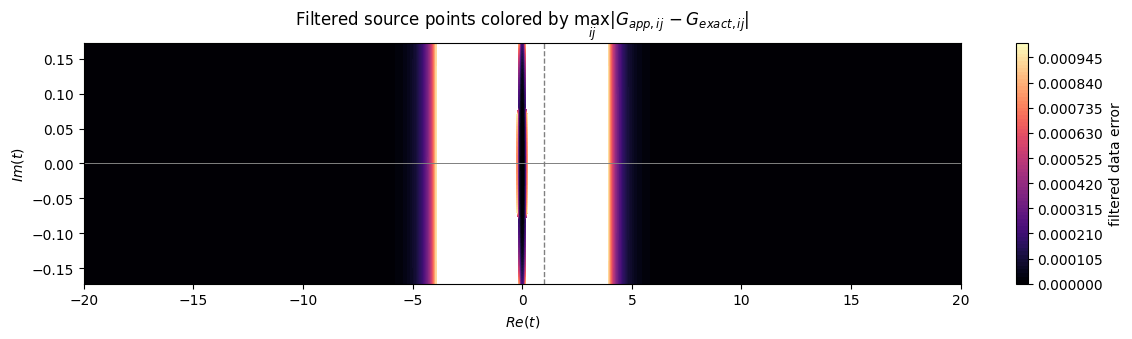

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3.5))
field = lattice_field_from_points(t_app, app_error, source_real_grid, source_imag_grid)
cf = ax.contourf(source_real_grid, source_imag_grid, field, levels=80, cmap="magma")
ax.plot(source_boundary.real, source_boundary.imag, color="k", linewidth=0.8)
ax.axhline(0, color="0.5", linewidth=0.7)
ax.axvline(1, color="gray", linestyle="--", linewidth=1)
ax.set_title(r"Filtered source points colored by $\max_{ij}|G_{app,ij} - G_{exact,ij}|$")
ax.set_xlabel(r"$Re(t)$")
ax.set_ylabel(r"$Im(t)$")
ax.set_ylim(-1.15 *aaa_tube_delta , 1.15 * aaa_tube_delta)
fig.colorbar(cf, ax=ax, label="filtered data error")
fig.tight_layout()
plt.show()


In [ ]:
# Fit scalar AAA_tube interpolants for G_00 and G_01.
r00 = AAA_tube(
    t_app,
    G_app[:, 0, 0],
    rtol=max_error,
    max_terms=20,
    delta=aaa_tube_delta,
    Ns=aaa_tube_Ns,
    tube_real_window=aaa_tube_real_window,
)

r01 = AAA_tube(
    t_app,
    G_app[:, 0, 1],
    rtol=max_error,
    max_terms=20,
    delta=aaa_tube_delta,
    Ns=aaa_tube_Ns,
    tube_real_window=aaa_tube_real_window,
)


AAA_tube final poles: [ 0.87792821-2.55124914j -0.90369273-1.9658529j   0.8503901 +2.54221512j
 -0.88220584+1.97137576j]
AAA_tube tube real interval: (-20.0, 20.0)
AAA_tube tube delta: 0.15
AAA_tube poles inside tube: []
AAA_tube maximum boundary |r(z)|: 0.011675994417887992
AAA_tube final max_error: 0.00031806187367201827
AAA_tube target max_error: 0.001
AAA_tube using best tube-safe iterate before max_terms.
AAA_tube warning constraints satisfied:
  max_error <= target: False
  poles outside tube: True
  boundary max < 1: True
AAA_tube warning final max_error: 0.001633454067203581
AAA_tube warning target max_error: 0.001
AAA_tube final poles: [ 3.6052462 +2.43565827j -0.61451721+2.46947277j  0.2400967 -2.73863245j
  0.5022294 +0.81614592j -0.70581114+0.55470222j -0.57426821-0.71850978j
  0.54702178-0.60764981j]
AAA_tube tube real interval: (-20.0, 20.0)
AAA_tube tube delta: 0.15
AAA_tube poles inside tube: []
AAA_tube maximum boundary |r(z)|: 0.245896033149677
AAA_tube final max_erro

/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/t_interpolation/../_bary_rational.py:67: RuntimeWarning: AAA_tube failed to satisfy all constraints within 20 iterations.
  self._compute_weights(z, f, **kwargs)


In [ ]:
# Evaluate exact and AAA interpolation on the full evaluation tube.
eval_real_grid, eval_imag_grid, eval_t_grid = make_tube_lattice(
    eval_tube_real_window,
    eval_tube_delta,
    eval_N_real,
    eval_N_imag,
)
eval_t_values = eval_t_grid.ravel()
eval_boundary = tube_boundary(eval_tube_real_window, eval_tube_delta)

G_exact_eval = compute_exact_t(eval_t_values, np.array([wn[n_fit]]), U, beta)[:, 0]
G00_aaa_eval = r00(eval_t_values)
G01_aaa_eval = r01(eval_t_values)

print("evaluation tube grid shape:", eval_t_grid.shape)
print("evaluation point count:", eval_t_values.size)
print("G_exact_eval shape:", G_exact_eval.shape)


evaluation tube grid shape: (201, 501)
evaluation point count: 100701
G_exact_eval shape: (100701, 2, 2)


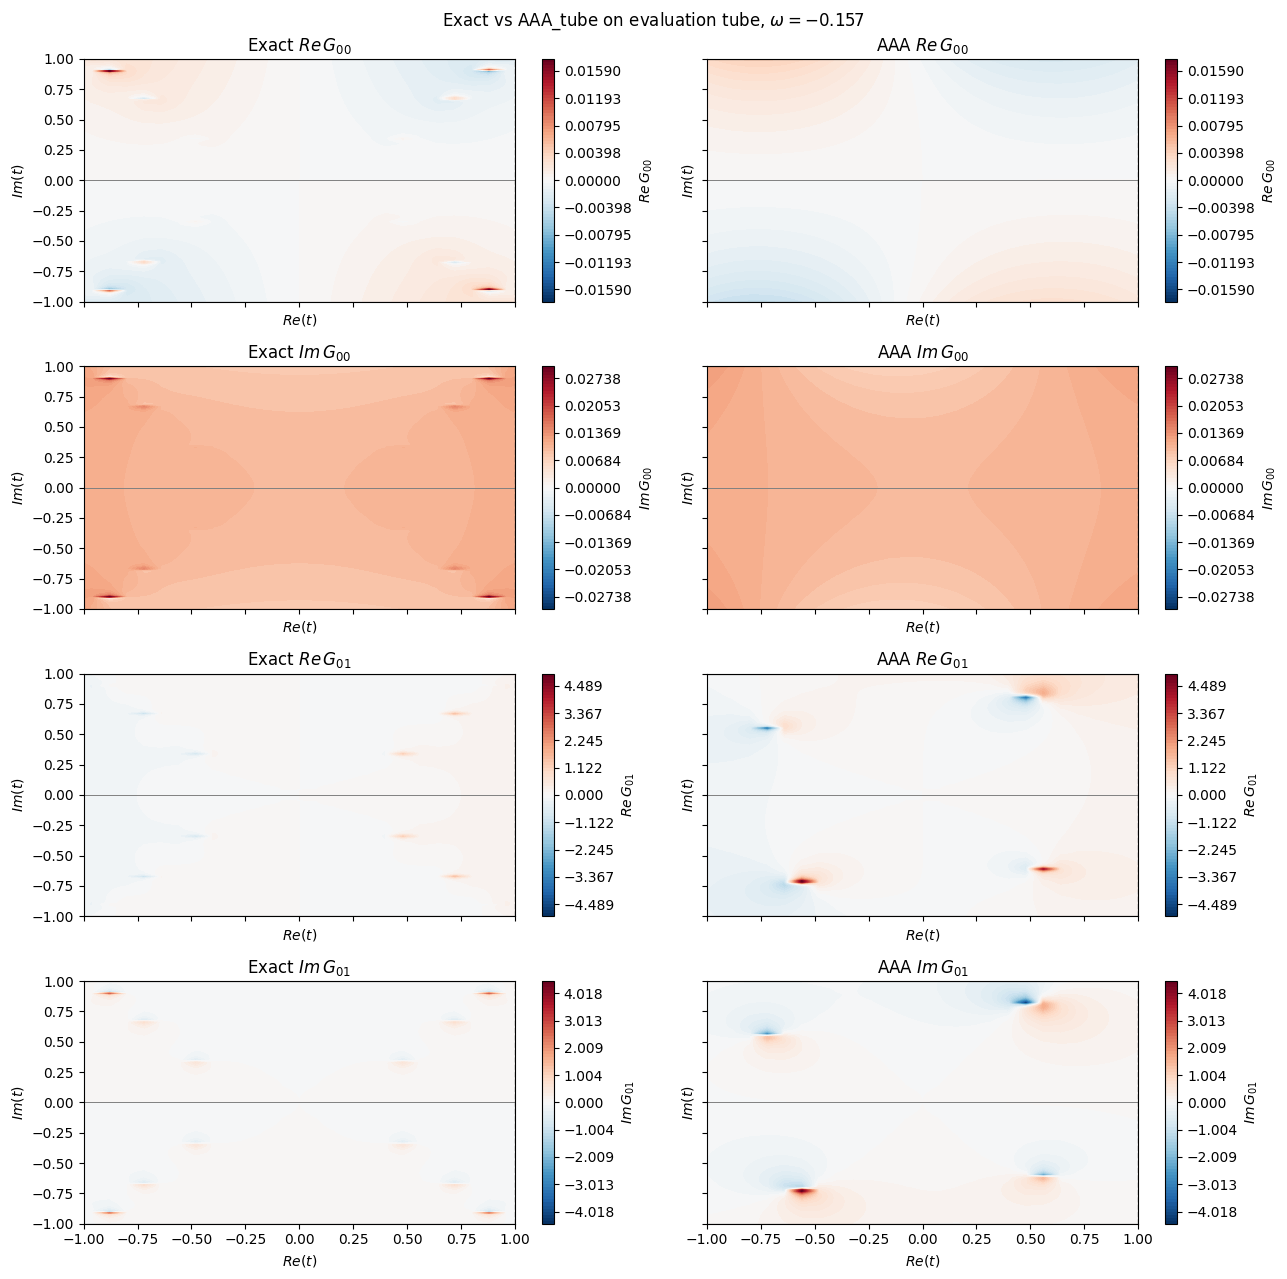

In [ ]:
# Exact on the left, AAA interpolation on the right over the whole evaluation tube.
comparison_components = [
    (G_exact_eval[:, 0, 0].real, G00_aaa_eval.real, r"$Re\,G_{00}$"),
    (G_exact_eval[:, 0, 0].imag, G00_aaa_eval.imag, r"$Im\,G_{00}$"),
    (G_exact_eval[:, 0, 1].real, G01_aaa_eval.real, r"$Re\,G_{01}$"),
    (G_exact_eval[:, 0, 1].imag, G01_aaa_eval.imag, r"$Im\,G_{01}$"),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 13), sharex=True, sharey=True)
for row, (exact_values, aaa_values, title) in enumerate(comparison_components):
    exact_field = exact_values.reshape(eval_real_grid.shape)
    aaa_field = aaa_values.reshape(eval_real_grid.shape)
    vmax = np.nanmax(np.abs([exact_field, aaa_field]))
    levels = np.linspace(-vmax, vmax, 81) if vmax > 0 else 80

    panels = [
        (exact_field, "Exact " + title),
        (aaa_field, "AAA " + title),
    ]
    for col, (field, panel_title) in enumerate(panels):
        ax = axes[row, col]
        cf = ax.contourf(eval_real_grid, eval_imag_grid, field, levels=levels, cmap="RdBu_r")
        ax.plot(eval_boundary.real, eval_boundary.imag, color="k", linewidth=0.8)
        ax.axhline(0, color="0.5", linewidth=0.7)
        ax.axvline(1, color="gray", linestyle="--", linewidth=1)
        ax.set_title(panel_title)
        ax.set_xlabel(r"$Re(t)$")
        ax.set_ylabel(r"$Im(t)$")
        ax.set_ylim(-1, 1)
        ax.set_xlim(-1, 1)
        fig.colorbar(cf, ax=ax, label=title)

fig.suptitle(rf"Exact vs AAA_tube on evaluation tube, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()


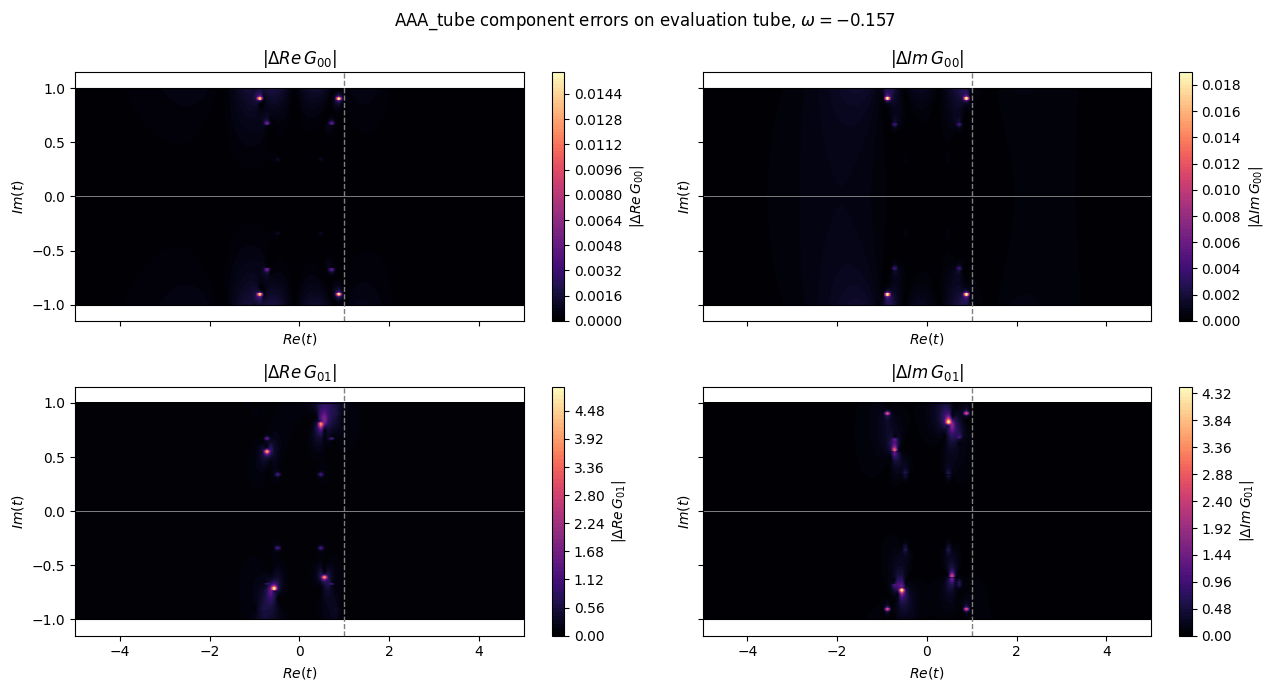

In [ ]:
# Component error of the AAA interpolation on the whole evaluation tube.
error_components = [
    (np.abs(G00_aaa_eval.real - G_exact_eval[:, 0, 0].real), r"$|\Delta Re\,G_{00}|$"),
    (np.abs(G00_aaa_eval.imag - G_exact_eval[:, 0, 0].imag), r"$|\Delta Im\,G_{00}|$"),
    (np.abs(G01_aaa_eval.real - G_exact_eval[:, 0, 1].real), r"$|\Delta Re\,G_{01}|$"),
    (np.abs(G01_aaa_eval.imag - G_exact_eval[:, 0, 1].imag), r"$|\Delta Im\,G_{01}|$"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
for ax, (values, title) in zip(axes.ravel(), error_components):
    field = values.reshape(eval_real_grid.shape)
    cf = ax.contourf(eval_real_grid, eval_imag_grid, field, levels=80, cmap="magma")
    ax.plot(eval_boundary.real, eval_boundary.imag, color="k", linewidth=0.8)
    ax.axhline(0, color="0.5", linewidth=0.7)
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(r"$Re(t)$")
    ax.set_ylabel(r"$Im(t)$")
    ax.set_ylim(-1.15 * eval_tube_delta, 1.15 * eval_tube_delta)
    ax.set_xlim(-5, 5)
    fig.colorbar(cf, ax=ax, label=title)

fig.suptitle(rf"AAA_tube component errors on evaluation tube, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()


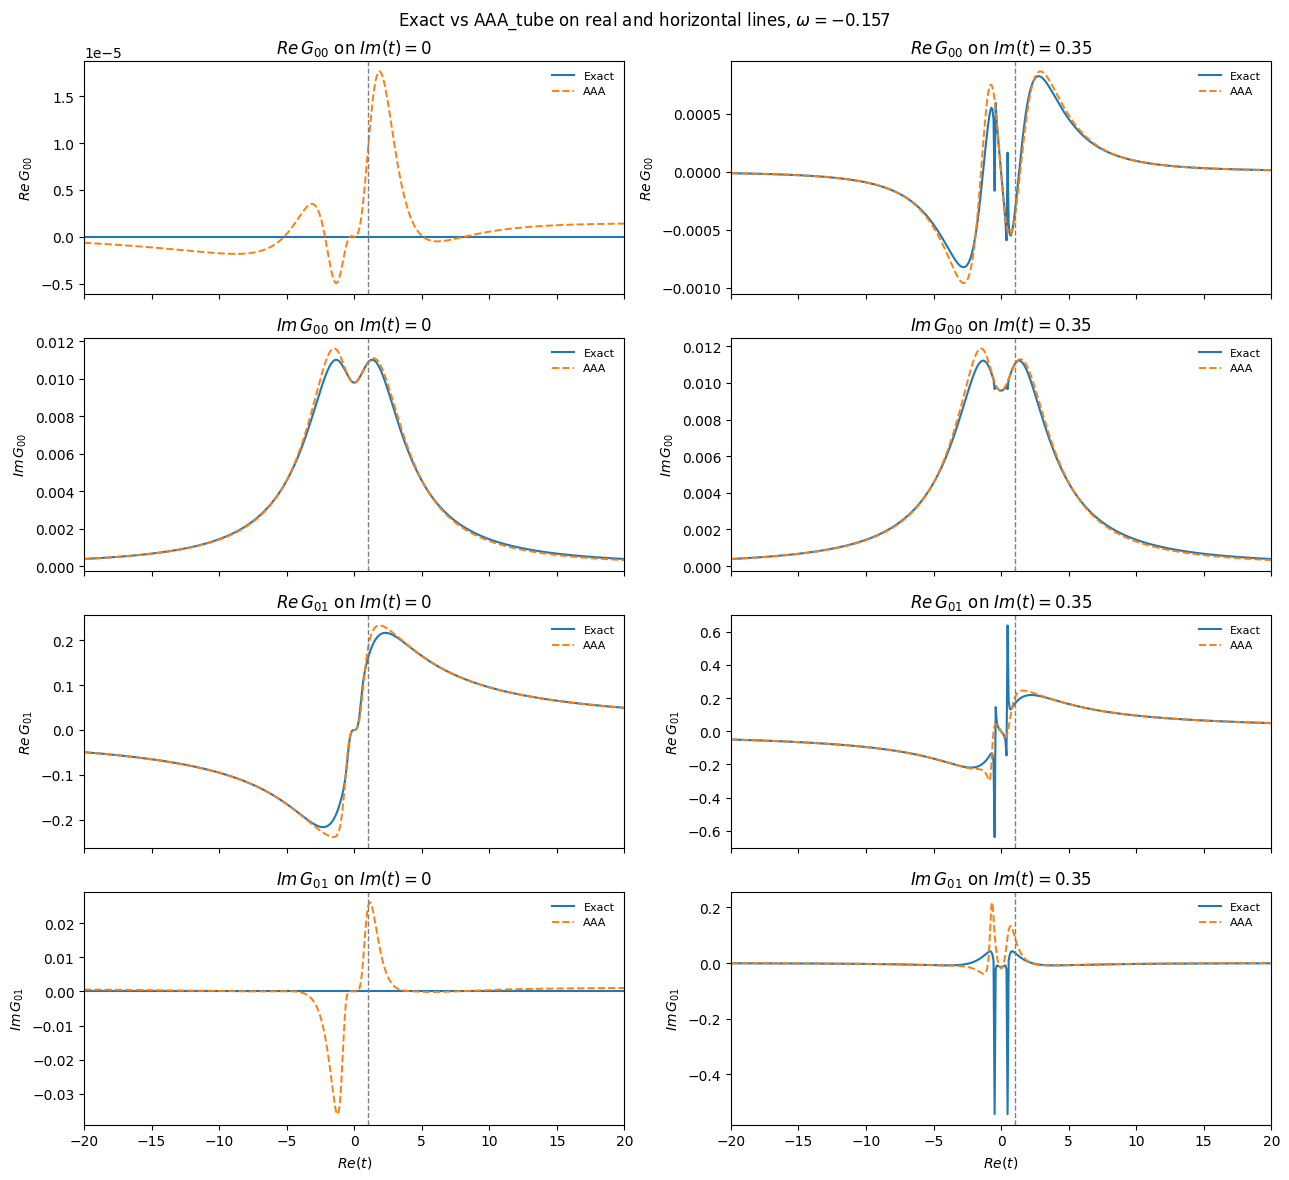

In [ ]:
# Compare AAA and exact on one-dimensional paths.
# Edit Nt and eta here if you want a denser line or a different horizontal slice.
Nt = 501
eta = 0.35

t_line_real = np.linspace(-T, T, Nt)
t_line_complex = t_line_real + eta * 1j

G_exact_line_real = compute_exact_t(t_line_real, np.array([wn[n_fit]]), U, beta)[:, 0]
G_exact_line_complex = compute_exact_t(t_line_complex, np.array([wn[n_fit]]), U, beta)[:, 0]

G00_aaa_line_real = r00(t_line_real)
G01_aaa_line_real = r01(t_line_real)
G00_aaa_line_complex = r00(t_line_complex)
G01_aaa_line_complex = r01(t_line_complex)

line_components = [
    (
        G_exact_line_real[:, 0, 0].real,
        G00_aaa_line_real.real,
        G_exact_line_complex[:, 0, 0].real,
        G00_aaa_line_complex.real,
        r"$Re\,G_{00}$",
    ),
    (
        G_exact_line_real[:, 0, 0].imag,
        G00_aaa_line_real.imag,
        G_exact_line_complex[:, 0, 0].imag,
        G00_aaa_line_complex.imag,
        r"$Im\,G_{00}$",
    ),
    (
        G_exact_line_real[:, 0, 1].real,
        G01_aaa_line_real.real,
        G_exact_line_complex[:, 0, 1].real,
        G01_aaa_line_complex.real,
        r"$Re\,G_{01}$",
    ),
    (
        G_exact_line_real[:, 0, 1].imag,
        G01_aaa_line_real.imag,
        G_exact_line_complex[:, 0, 1].imag,
        G01_aaa_line_complex.imag,
        r"$Im\,G_{01}$",
    ),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
for row, (exact_real, aaa_real, exact_complex, aaa_complex, title) in enumerate(line_components):
    axes[row, 0].plot(t_line_real, exact_real, color="tab:blue", linewidth=1.5, label="Exact")
    axes[row, 0].plot(t_line_real, aaa_real, color="tab:orange", linestyle="--", linewidth=1.4, label="AAA")
    axes[row, 0].set_title(title + r" on $Im(t)=0$")

    axes[row, 1].plot(t_line_real, exact_complex, color="tab:blue", linewidth=1.5, label="Exact")
    axes[row, 1].plot(t_line_real, aaa_complex, color="tab:orange", linestyle="--", linewidth=1.4, label="AAA")
    axes[row, 1].set_title(title + rf" on $Im(t)={eta:g}$")

    for ax in axes[row, :]:
        ax.axvline(1, color="gray", linestyle="--", linewidth=1)
        ax.set_xlim(-T, T)
        ax.set_ylabel(title)
        ax.legend(frameon=False, fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel(r"$Re(t)$")

fig.suptitle(rf"Exact vs AAA_tube on real and horizontal lines, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()


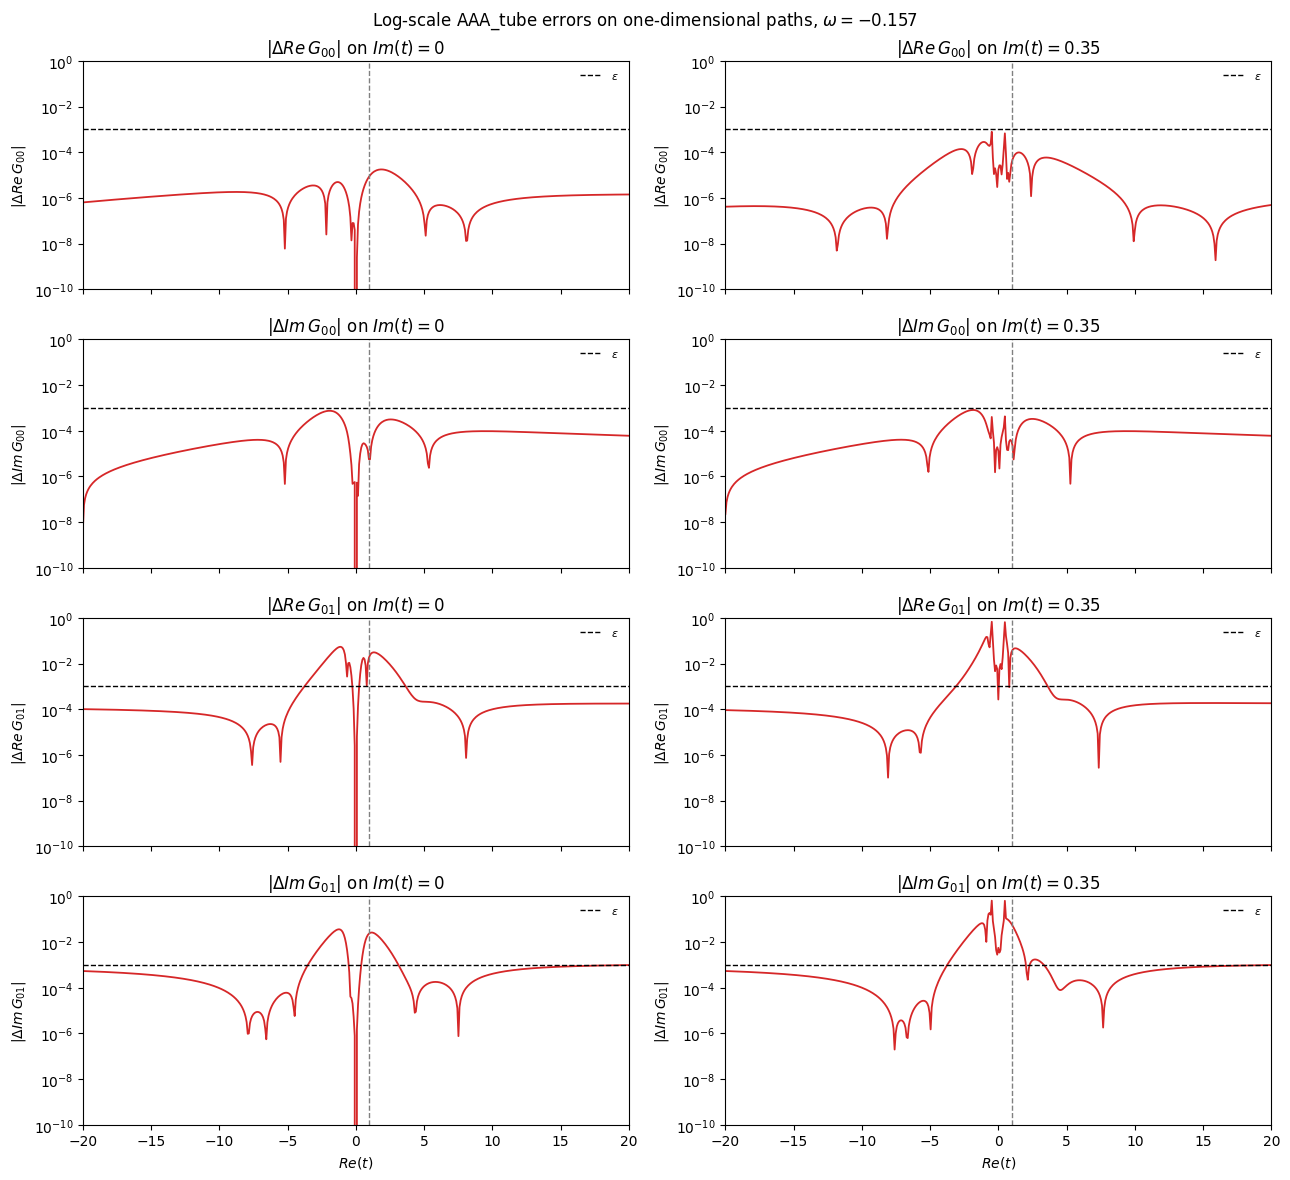

In [ ]:
# Log-scale errors for the one-dimensional paths.
line_error_components = [
    (
        np.abs(G00_aaa_line_real.real - G_exact_line_real[:, 0, 0].real),
        np.abs(G00_aaa_line_complex.real - G_exact_line_complex[:, 0, 0].real),
        r"$|\Delta Re\,G_{00}|$",
    ),
    (
        np.abs(G00_aaa_line_real.imag - G_exact_line_real[:, 0, 0].imag),
        np.abs(G00_aaa_line_complex.imag - G_exact_line_complex[:, 0, 0].imag),
        r"$|\Delta Im\,G_{00}|$",
    ),
    (
        np.abs(G01_aaa_line_real.real - G_exact_line_real[:, 0, 1].real),
        np.abs(G01_aaa_line_complex.real - G_exact_line_complex[:, 0, 1].real),
        r"$|\Delta Re\,G_{01}|$",
    ),
    (
        np.abs(G01_aaa_line_real.imag - G_exact_line_real[:, 0, 1].imag),
        np.abs(G01_aaa_line_complex.imag - G_exact_line_complex[:, 0, 1].imag),
        r"$|\Delta Im\,G_{01}|$",
    ),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
for row, (err_real, err_complex, title) in enumerate(line_error_components):
    axes[row, 0].semilogy(t_line_real, err_real, color="tab:red", linewidth=1.3)
    axes[row, 0].axhline(epsilon, color="k", linestyle="--", linewidth=1, label=r"$\epsilon$")
    axes[row, 0].set_title(title + r" on $Im(t)=0$")

    axes[row, 1].semilogy(t_line_real, err_complex, color="tab:red", linewidth=1.3)
    axes[row, 1].axhline(epsilon, color="k", linestyle="--", linewidth=1, label=r"$\epsilon$")
    axes[row, 1].set_title(title + rf" on $Im(t)={eta:g}$")

    for ax in axes[row, :]:
        ax.axvline(1, color="gray", linestyle="--", linewidth=1)
        ax.set_xlim(-T, T)
        ax.set_ylim(1e-10, 1)
        ax.set_ylabel(title)
        ax.legend(frameon=False, fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel(r"$Re(t)$")

fig.suptitle(rf"Log-scale AAA_tube errors on one-dimensional paths, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()
